In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from google.colab import files
uploaded = files.upload()

Saving scuderia-ferrari-f1.jpg to scuderia-ferrari-f1.jpg


(np.float64(-0.5), np.float64(1023.5), np.float64(682.5), np.float64(-0.5))

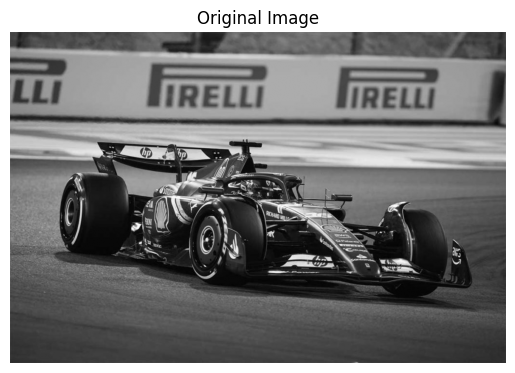

In [3]:
image = cv2.imread("scuderia-ferrari-f1.jpg",0)

plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

The image scuderia-ferrari-f1.jpg was loaded using OpenCV.

The parameter 0 converts the image into grayscale format, which is commonly used in edge detection algorithms.

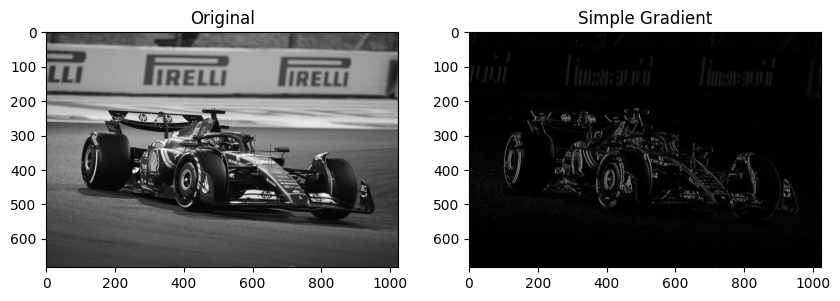

In [4]:
kernel = np.array([[0,0,0],
                   [-1/2,0,1/2],
                   [0,0,0]])

edges = cv2.filter2D(image, cv2.CV_64F , kernel)

plt.figure(figsize=(10,4))

plt.subplot(121)
plt.imshow(image,cmap="gray")
plt.title("Original")

plt.subplot(122)
plt.imshow(np.abs(edges),cmap="gray")
plt.title("Simple Gradient")

plt.show()

In this task, a simple gradient operator was applied to detect edges in the image.

The kernel detects intensity changes between neighboring pixels, which helps identify image boundaries.

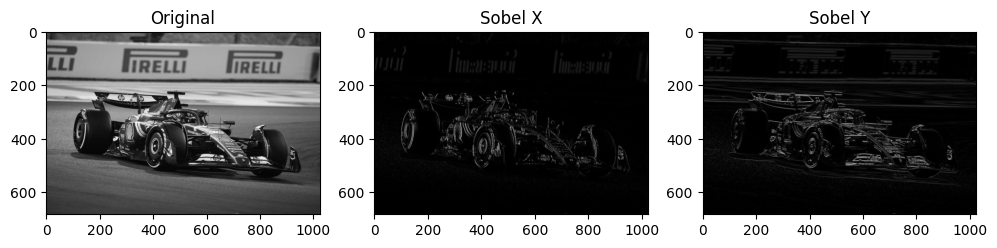

In [5]:
sobelx = cv2.Sobel(image, cv2.CV_64F,1,0,ksize=3)
sobely = cv2.Sobel(image, cv2.CV_64F,0,1,ksize=3)

plt.figure(figsize=(12,4))

plt.subplot(131)
plt.imshow(image,cmap="gray")
plt.title("Original")

plt.subplot(132)
plt.imshow(np.abs(sobelx),cmap="gray")
plt.title("Sobel X")

plt.subplot(133)
plt.imshow(np.abs(sobely),cmap="gray")
plt.title("Sobel Y")

plt.show()

The Sobel operator was used to detect edges in two directions:


Sobel X detects horizontal edges.

Sobel Y detects vertical edges.

This method provides better edge detection compared to the simple gradient method.

(np.float64(-0.5), np.float64(1023.5), np.float64(682.5), np.float64(-0.5))

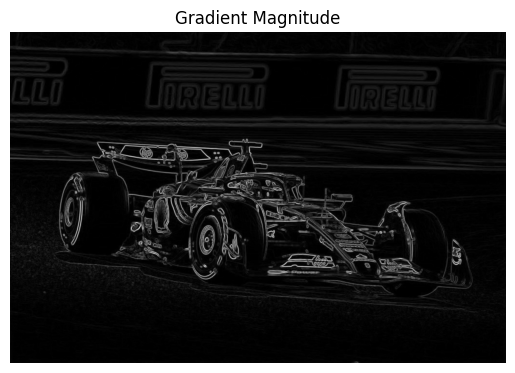

In [6]:
magnitude = np.sqrt(sobelx**2 + sobely**2)

plt.imshow(magnitude,cmap="gray")
plt.title("Gradient Magnitude")
plt.axis("off")

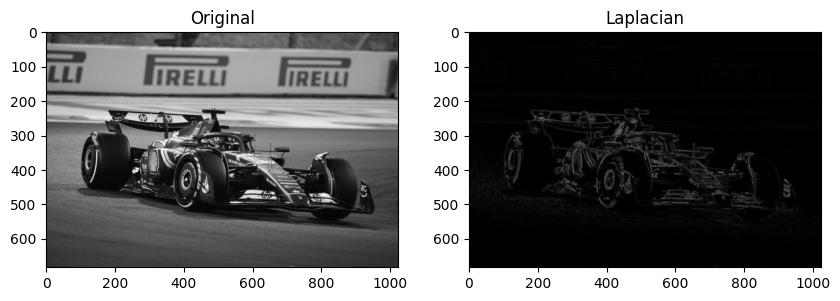

In [7]:
laplacian = cv2.Laplacian(image, cv2.CV_64F)

plt.figure(figsize=(10,4))

plt.subplot(121)
plt.imshow(image,cmap="gray")
plt.title("Original")

plt.subplot(122)
plt.imshow(np.abs(laplacian),cmap="gray")
plt.title("Laplacian")

plt.show()

The Laplacian operator calculates the second derivative of the image intensity.


It detects edges in all directions but can also be sensitive to noise.

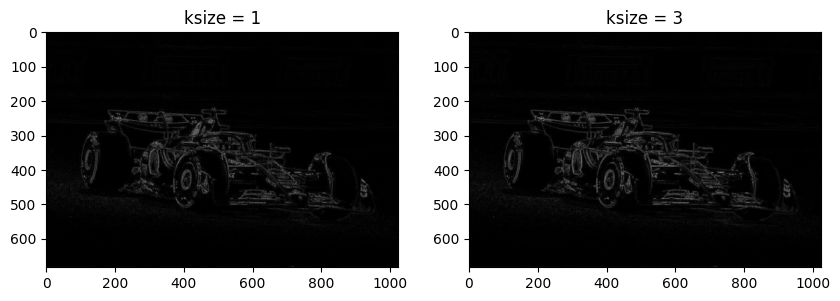

In [8]:
lap1 = cv2.Laplacian(image, cv2.CV_64F,ksize=1)
lap3 = cv2.Laplacian(image, cv2.CV_64F,ksize=3)

plt.figure(figsize=(10,4))

plt.subplot(121)
plt.imshow(np.abs(lap1),cmap="gray")
plt.title("ksize = 1")

plt.subplot(122)
plt.imshow(np.abs(lap3),cmap="gray")
plt.title("ksize = 3")

plt.show()

In this experiment, different kernel sizes were tested for the Laplacian operator.


Larger kernels usually produce smoother results but may reduce edge sharpness.

(np.float64(-0.5), np.float64(1023.5), np.float64(682.5), np.float64(-0.5))

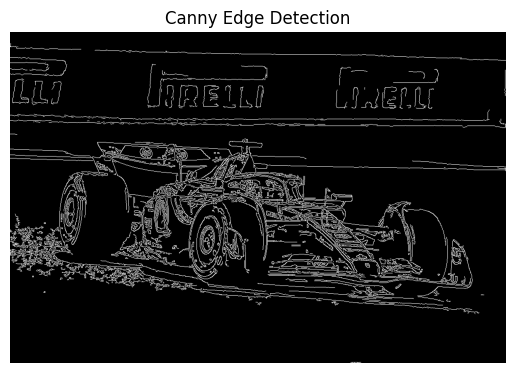

In [9]:
edges = cv2.Canny(image,50,150)

plt.imshow(edges,cmap="gray")
plt.title("Canny Edge Detection")
plt.axis("off")

The Canny edge detection algorithm was applied in this step.


This algorithm is widely used because it produces very accurate and clean edge detection results.

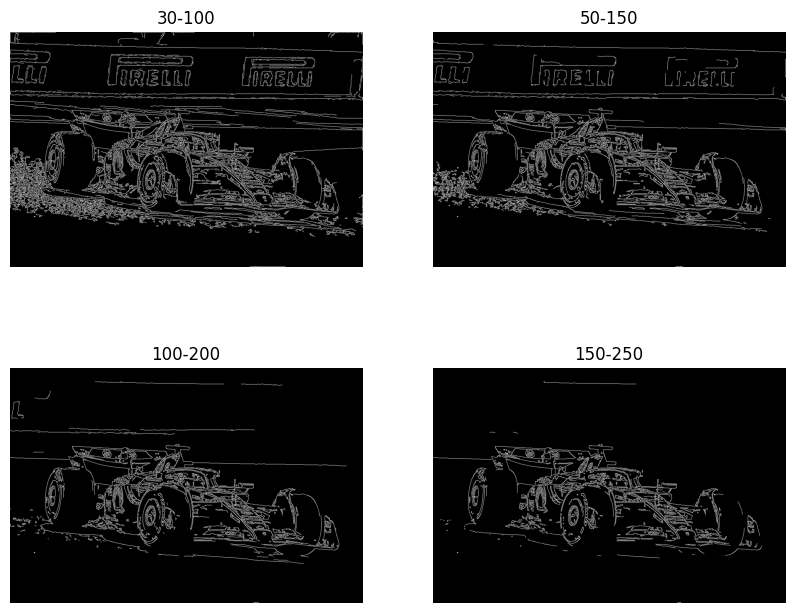

In [10]:
pairs = [(30,100),(50,150),(100,200),(150,250)]

plt.figure(figsize=(10,8))

for i,(t1,t2) in enumerate(pairs):

    e = cv2.Canny(image,t1,t2)

    plt.subplot(2,2,i+1)
    plt.imshow(e,cmap="gray")
    plt.title(f"{t1}-{t2}")
    plt.axis("off")

plt.show()

Different threshold values were tested in the Canny algorithm to observe how they affect edge detection results.

# **Title: Edge Detection Techniques in Image Processing**

Objective:
The objective of this experiment was to analyze and compare different edge detection techniques using OpenCV.


Methods Used:

Simple Gradient

Sobel Operator

Laplacian Operator

Canny Edge Detection


Experiment Description:
The image scuderia-ferrari-f1.jpg was used as the input image.
First, the image was converted to grayscale format. Then several edge detection algorithms were applied to identify object boundaries and intensity changes in the image.


Results:


The Simple Gradient method detected basic edges but produced limited results.

The Sobel operator improved edge detection by detecting horizontal and vertical gradients.

The Laplacian operator detected edges in all directions but was more sensitive to noise.

The Canny edge detector produced the clearest and most accurate edge detection results.

Conclusion:

Among all tested methods, the Canny Edge Detection algorithm produced the best results.
This is because the Canny method includes multiple steps such as noise reduction, gradient calculation, non-maximum suppression, and double thresholding, which significantly improve edge detection accuracy.